In [65]:
import nibabel as nib
import numpy as np
from skimage import measure
import pyvista as pv
import skshapes as sks
from IPython.display import Image
import tqdm as tqdm

INTERACTIVE_RENDERING = False

# Data loading & conversion to meshes

In [41]:
def clean_mesh(mesh, fill_holes_size=1000):
    """
    Clean mesh by:
    1. Filling holes/cavities
    2. Removing disconnected components (keeping only largest)
    
    Parameters
    ----------
    mesh : pv.PolyData
        Input mesh
    fill_holes_size : int
        Maximum hole size to fill (in terms of number of edges)
    
    Returns
    -------
    pv.PolyData
        Cleaned mesh
    """
    # 1. Fill holes to remove cavities
    mesh_filled = mesh.fill_holes(hole_size=fill_holes_size)
    
    # 2. Remove disconnected components - keep only largest
    # Use connectivity to identify connected components
    mesh_labeled = mesh_filled.connectivity()
    
    # Extract cells with label 0 (largest component)
    mesh_cleaned = mesh_labeled.extract_cells(mesh_labeled['RegionId'] == 0)
    
    return mesh_cleaned

def load_nifti_as_mesh(path, pass_band=0.05):
    """
    Load a NIfTI file, extract isosurface at 0.5, and return a smoothed mesh.
    
    Parameters
    ----------
    path : str
        Path to NIfTI file
    pass_band : float
        Pass band for smoothing between 0 and 2 (lower is smoother)
    
    Returns
    -------
    pv.PolyData
        Smoothed mesh extracted from NIfTI file
    """
    img = nib.load(path)
    data = img.get_fdata()
    spacing = img.header.get_zooms()
    grid = pv.ImageData()
    grid.dimensions = np.array(data.shape)
    grid.spacing = spacing  # CRUCIAL pour ne pas déformer le foie
    grid.point_data["values"] = data.flatten(order="F")

    mesh = grid.contour([0.5])

    # 4. Lissage préservant le volume (Taubin)
    # Indispensable pour l'aspect organique sans perdre la précision médicale
    mesh_smooth = mesh.smooth_taubin(n_iter=40, pass_band=pass_band)

    mesh_clean = clean_mesh(mesh_smooth)

    return mesh_clean

liver_pre = load_nifti_as_mesh('data/Patient 3 segmentation pre-ablation/PARTIES MOLLES AiCE 1.0-liver.nii.gz')
tumor_pre_1 = load_nifti_as_mesh('data/Patient 3 segmentation pre-ablation/PARTIES MOLLES AiCE 1.0-lesion-1.nii.gz')
tumor_pre_2 = load_nifti_as_mesh('data/Patient 3 segmentation pre-ablation/PARTIES MOLLES AiCE 1.0-lesion-2.nii.gz')
ref_pre_1 = load_nifti_as_mesh('data/Patient 3 segmentation pre-ablation/PARTIES MOLLES AiCE 1.0-repere-1.nii.gz')
ref_pre_2 = load_nifti_as_mesh('data/Patient 3 segmentation pre-ablation/PARTIES MOLLES AiCE 1.0-repere-2.nii.gz')
ref_pre_3 = load_nifti_as_mesh('data/Patient 3 segmentation pre-ablation/PARTIES MOLLES AiCE 1.0-repere-3.nii.gz')

liver_post = load_nifti_as_mesh('data/Patient 3 segmentation post-ablation/PARTIES MOLLES AiCE 1.0-liver-post-ablation.nii.gz')
ablation_post_1 = load_nifti_as_mesh('data/Patient 3 segmentation post-ablation/PARTIES MOLLES AiCE 1.0-zone-ablation-lesion-1.nii.gz')
ablation_post_2 = load_nifti_as_mesh('data/Patient 3 segmentation post-ablation/PARTIES MOLLES AiCE 1.0-zone-ablation-lesion-2.nii.gz')
ref_post_1 = load_nifti_as_mesh('data/Patient 3 segmentation post-ablation/PARTIES MOLLES AiCE 1.0-repere-1-postablation.nii.gz')
ref_post_2 = load_nifti_as_mesh('data/Patient 3 segmentation post-ablation/PARTIES MOLLES AiCE 1.0-repere-2-postablation.nii.gz')
ref_post_3 = load_nifti_as_mesh('data/Patient 3 segmentation post-ablation/PARTIES MOLLES AiCE 1.0-repere-3-post-ablation.nii.gz')

# Visualization

## Superposed

In [43]:
plotter = pv.Plotter(shape=(1, 1), off_screen=True, window_size=[1200, 600])
plotter.subplot(0, 0)
plotter.add_text(f"PRE-OP + POST-OP", font_size=12, color="white")
plotter.add_mesh(liver_pre, color="salmon", opacity=0.3, label="Liver PRE")
plotter.add_mesh(liver_post, color="salmon", opacity=0.3, label="Liver POST")
plotter.add_mesh(tumor_pre_1, color="red", label="Tumor 1 PRE")
plotter.add_mesh(tumor_pre_2, color="darkred", label="Tumor 2 PRE")
plotter.add_mesh(ablation_post_1, color="orange", label="Ablation 1 POST")
plotter.add_mesh(ablation_post_2, color="darkorange", label="Ablation 2 POST")
plotter.add_mesh(ref_pre_1, color="blue", point_size=10, render_points_as_spheres=True, label="Landmark 1 PRE")
plotter.add_mesh(ref_pre_2, color="cyan", point_size=10, render_points_as_spheres=True, label="Landmark 2 PRE")
plotter.add_mesh(ref_pre_3, color="magenta", point_size=10, render_points_as_spheres=True, label="Landmark 3 PRE")
plotter.add_mesh(ref_post_1, color="blue", point_size=10, render_points_as_spheres=True, label="Landmark 1 POST")
plotter.add_mesh(ref_post_2, color="cyan", point_size=10, render_points_as_spheres=True, label="Landmark 2 POST")
plotter.add_mesh(ref_post_3, color="magenta", point_size=10, render_points_as_spheres=True, label="Landmark 3 POST")
plotter.add_legend(face=None)
plotter.view_xy()
if INTERACTIVE_RENDERING:
    plotter.show()
else:
    plotter.screenshot("liver_superposed.png")
    plotter.close()
    display(Image("liver_superposed.png"))

Widget(value='<iframe src="http://localhost:64833/index.html?ui=P_0x16bfc8880_5&reconnect=auto" class="pyvista…

This visualization shows the shape needs to be rigidly registrated.

## Rigid Registration (Translation + Rotation)

Computing distance weights (prioritizing points far from ablation)...

PRE-OP weight stats - min: 0.5645, max: 1.0000, mean: 0.8632
POST-OP weight stats - min: 0.6291, max: 1.0000, mean: 0.9118


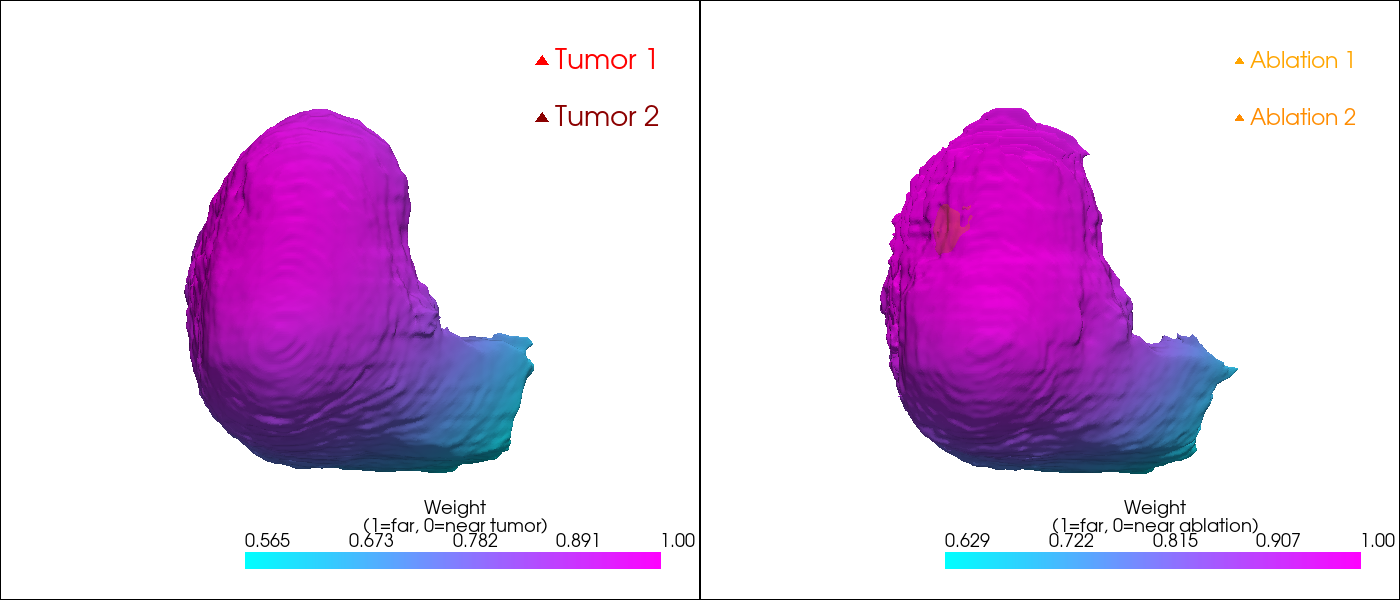

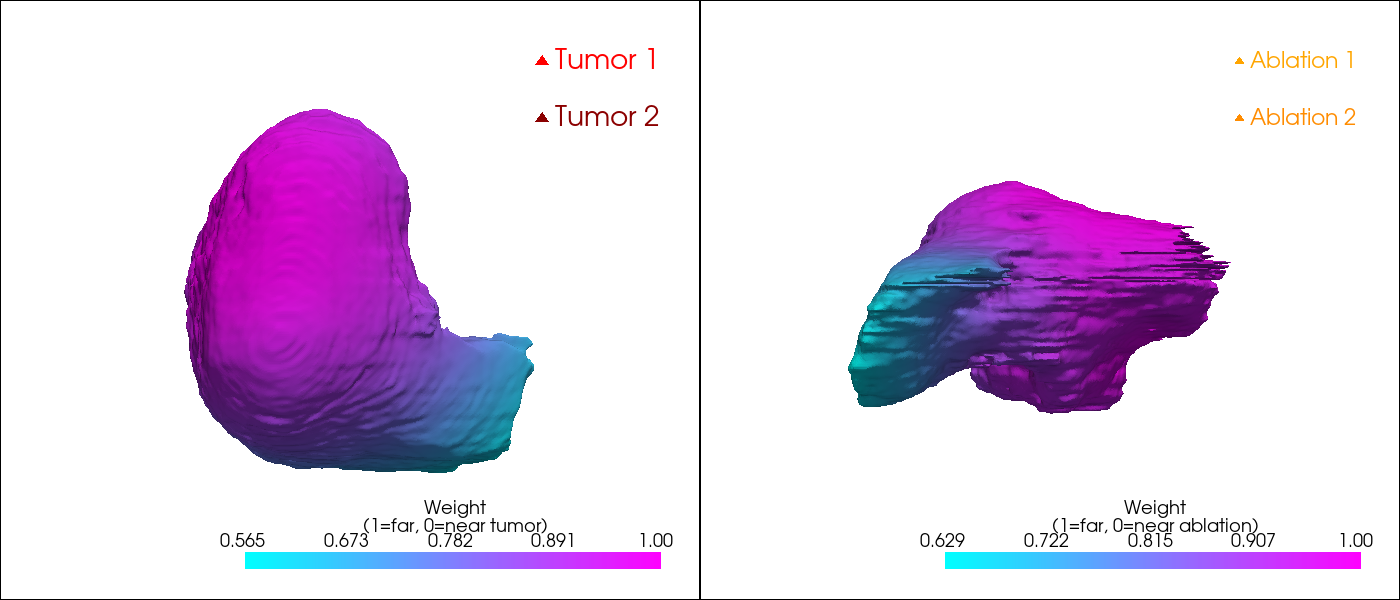

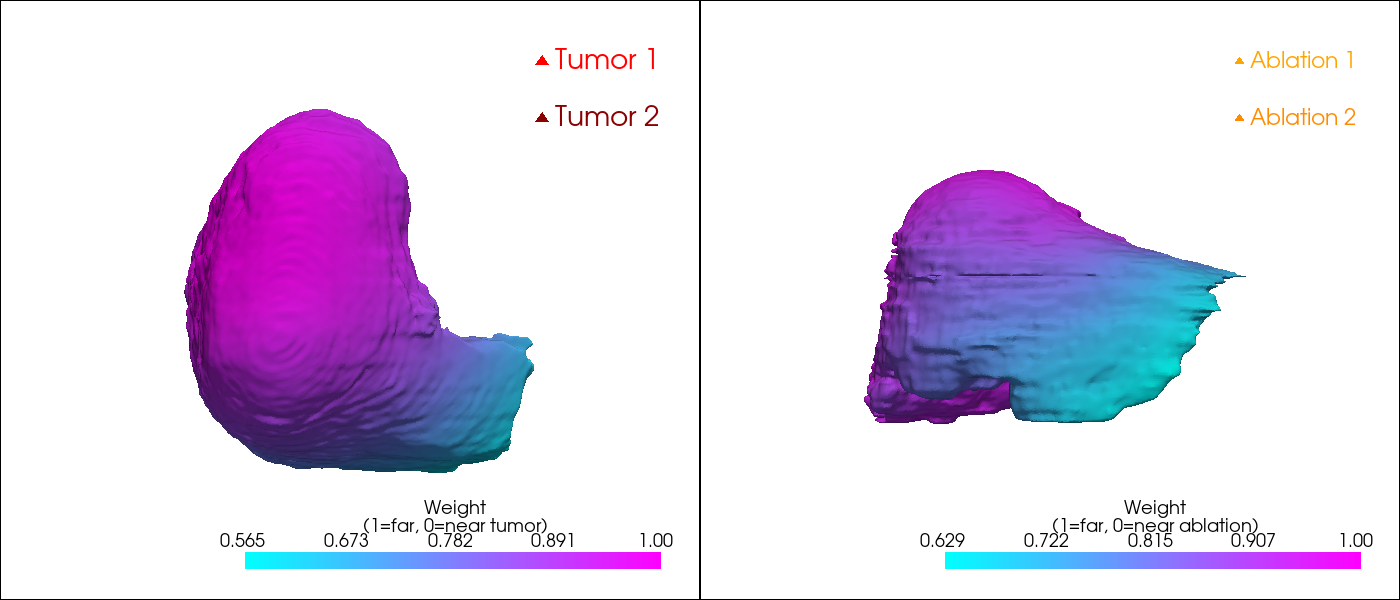

In [ ]:
from scipy.spatial import cKDTree
from scipy.spatial.distance import cdist

def compute_distance_weights(mesh_points, deform_mesh1, deform_mesh2, sigma=200.0):
    """
    Compute weights based on distance from deformable structures.
    Points far from deformations get higher weights.
    
    Parameters
    ----------
    mesh_points : ndarray, shape (N, 3)
        Points to weight
    deform_mesh1 : pv.PolyData
        First deformable structure (e.g., tumor_pre)
    deform_mesh2 : pv.PolyData
        Second deformable structure (e.g., tumor_pre_2)
    sigma : float
        Gaussian decay constant (higher = weights drop off slower with distance)
    
    Returns
    -------
    ndarray, shape (N,)
        Weights between 0 and 1
    """
    # Compute distance to closest deformable structure
    deform_points = np.vstack([deform_mesh1.points, deform_mesh2.points])
    tree = cKDTree(deform_points)
    distances, _ = tree.query(mesh_points)
    
    # Convert distances to weights using Gaussian: w = exp(-(d/sigma)^2)
    # This gives high weight to distant points, low weight to nearby points
    weights = np.exp(-(distances / sigma) ** 2)
    
    return weights

# --- COMPUTE DISTANCE-BASED WEIGHTS ---
print("Computing distance weights (prioritizing points far from ablation)...\n")

# For PRE-OP: prioritize points far from tumors
source_weights = compute_distance_weights(
    liver_pre.points, 
    tumor_pre_1, 
    tumor_pre_2, 
    sigma=200.0
)
print(f"PRE-OP weight stats - min: {source_weights.min():.4f}, max: {source_weights.max():.4f}, mean: {source_weights.mean():.4f}")

# For POST-OP: prioritize points far from ablation zones
target_weights = compute_distance_weights(
    liver_post.points, 
    ablation_post_1, 
    ablation_post_2, 
    sigma=200.0
)
print(f"POST-OP weight stats - min: {target_weights.min():.4f}, max: {target_weights.max():.4f}, mean: {target_weights.mean():.4f}")

# Visualize weights as color gradient on livers
plotter = pv.Plotter(shape=(1, 2), off_screen=True, window_size=[1400, 600])

# PRE-OP: Show weights (distance from tumors)
plotter.subplot(0, 0)
plotter.add_text("PRE-OP Liver - Weights (distance from tumors)", font_size=12, color="white")
liver_pre_with_weights = liver_pre.copy()
liver_pre_with_weights["weights"] = source_weights
plotter.add_mesh(
    liver_pre_with_weights, 
    scalars="weights",
    cmap="cool",  # Blue (low weight) to cyan (high weight)
    show_scalar_bar=True,
    scalar_bar_args={"title": "Weight\n(1=far, 0=near tumor)"}
)
plotter.add_mesh(tumor_pre_1, color="red", opacity=0.3, label="Tumor 1")
plotter.add_mesh(tumor_pre_2, color="darkred", opacity=0.3, label="Tumor 2")
plotter.add_legend(face=None)
plotter.view_xy()

# POST-OP: Show weights (distance from ablations)
plotter.subplot(0, 1)
plotter.add_text("POST-OP Liver - Weights (distance from ablation)", font_size=12, color="white")
liver_post_with_weights = liver_post.copy()
liver_post_with_weights["weights"] = target_weights
plotter.add_mesh(
    liver_post_with_weights, 
    scalars="weights",
    cmap="cool",  # Blue (low weight) to cyan (high weight)
    show_scalar_bar=True,
    scalar_bar_args={"title": "Weight\n(1=far, 0=near ablation)"}
)
plotter.add_mesh(ablation_post_1, color="orange", opacity=0.3, label="Ablation 1")
plotter.add_mesh(ablation_post_2, color="darkorange", opacity=0.3, label="Ablation 2")
plotter.add_legend(face=None)

if INTERACTIVE_RENDERING:
    plotter.view_xy()
    plotter.show()
else:
    plotter.view_xy()
    plotter.screenshot("liver_weights_visualization_xy.png")
    display(Image("liver_weights_visualization_xy.png"))
    plotter.view_yz()
    plotter.screenshot("liver_weights_visualization_yz.png")
    display(Image("liver_weights_visualization_yz.png"))
    plotter.view_xz()
    plotter.screenshot("liver_weights_visualization_xz.png")
    plotter.close()
    display(Image("liver_weights_visualization_xz.png"))

In [62]:
# --- WEIGHTED RIGID REGISTRATION OF LIVERS USING ICP (SCIPY) ---
def rigid_icp_weighted(source_points, target_points, source_weights=None, target_weights=None, 
                       max_iterations=50, tolerance=1e-4):
    """
    Weighted Rigid ICP (Iterative Closest Point) registration using scipy.
    Returns rotation matrix R and translation vector t.
    
    Parameters
    ----------
    source_points : ndarray
        Source point cloud
    target_points : ndarray
        Target point cloud
    source_weights : ndarray, optional
        Weights for source points (higher = more important)
    target_weights : ndarray, optional
        Weights for target points (higher = more important)
    max_iterations : int
        Maximum iterations
    tolerance : float
        Convergence tolerance
    
    Returns
    -------
    R : ndarray, shape (3, 3)
        Rotation matrix
    t : ndarray, shape (3,)
        Translation vector
    """
    source_points = np.array(source_points, dtype=np.float32)
    target_points = np.array(target_points, dtype=np.float32)
    
    # Initialize weights if not provided
    if source_weights is None:
        source_weights = np.ones(len(source_points))
    else:
        source_weights = np.array(source_weights, dtype=np.float32)
    
    if target_weights is None:
        target_weights = np.ones(len(target_points))
    else:
        target_weights = np.array(target_weights, dtype=np.float32)
    
    # Initialize transformation
    R = np.eye(3)
    t = np.mean(target_points, axis=0) - np.mean(source_points, axis=0)
    
    for iteration in tqdm.tqdm(range(max_iterations), desc="Weighted ICP iterations"):
        # Transform source points
        source_transformed = (source_points @ R.T) + t
        
        # Find nearest neighbors in target
        tree = cKDTree(target_points)
        distances, indices = tree.query(source_transformed)
        
        # Get target weights for matched points
        target_matched_weights = target_weights[indices]
        # Combine source and target weights
        combined_weights = source_weights * target_matched_weights
        
        # Compute weighted centroids
        weight_sum = combined_weights.sum()
        source_weighted_mean = (source_transformed.T * combined_weights).sum(axis=1) / weight_sum
        target_matched = target_points[indices]
        target_weighted_mean = (target_matched.T * combined_weights).sum(axis=1) / weight_sum
        
        # Center points
        source_centered = source_transformed - source_weighted_mean
        target_centered = target_matched - target_weighted_mean
        
        # Weighted covariance matrix
        H = (source_centered.T * combined_weights) @ target_centered
        
        # Compute optimal rotation via SVD (Procrustes)
        U, S, Vt = np.linalg.svd(H)
        R_new = Vt.T @ U.T
        
        # Ensure proper rotation (det = 1)
        if np.linalg.det(R_new) < 0:
            Vt[-1, :] *= -1
            R_new = Vt.T @ U.T
        
        # Compute translation
        t_new = target_weighted_mean - (source_weighted_mean @ R_new.T)
        
        # Check convergence
        delta_R = np.linalg.norm(R_new - R)
        delta_t = np.linalg.norm(t_new - t)
        
        R = R_new
        t = t_new
        
        if delta_R < tolerance and delta_t < tolerance:
            print(f"Converged at iteration {iteration+1}")
            break
    
    return R, t

print("Running Weighted Rigid ICP registration (prioritizing stable points)...")

R, t = rigid_icp_weighted(
    source_points=liver_pre.points,
    target_points=liver_post.points,
    # source_weights=source_weights,
    # target_weights=target_weights,
    max_iterations=200,
    tolerance=1e-10
)

print(f"✓ Registration complete")

# --- APPLY TRANSFORMATION TO ALL PRE-OP STRUCTURES ---
def apply_rigid_transform(mesh_pyvista, R, t):
    """Apply rigid transformation (rotation + translation) to PyVista mesh."""
    transformed_mesh = mesh_pyvista.copy()
    # Apply: X' = X @ R^T + t
    transformed_points = (mesh_pyvista.points @ R.T) + t
    transformed_mesh.points = transformed_points
    return transformed_mesh

# Apply transformation to all pre-op structures
liver_pre_aligned = apply_rigid_transform(liver_pre, R, t)
tumor_pre_1_aligned = apply_rigid_transform(tumor_pre_1, R, t)
tumor_pre_2_aligned = apply_rigid_transform(tumor_pre_2, R, t)
ref_pre_1_aligned = apply_rigid_transform(ref_pre_1, R, t)
ref_pre_2_aligned = apply_rigid_transform(ref_pre_2, R, t)
ref_pre_3_aligned = apply_rigid_transform(ref_pre_3, R, t)

print("\n✅ Weighted rigid transformation applied to all pre-op structures")

Running Weighted Rigid ICP registration (prioritizing stable points)...


Weighted ICP iterations:   0%|          | 0/200 [00:00<?, ?it/s]

Weighted ICP iterations: 100%|██████████| 200/200 [04:59<00:00,  1.50s/it]

✓ Registration complete

✅ Weighted rigid transformation applied to all pre-op structures


In [ ]:
# --- RIGID REGISTRATION USING OPEN3D ICP ---
import open3d as o3d

def mesh_to_o3d_pointcloud(mesh_pyvista):
    """Convert PyVista mesh to Open3D PointCloud."""
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(mesh_pyvista.points)
    return pcd

# Convert to Open3D point clouds
liver_pre_o3d = mesh_to_o3d_pointcloud(liver_pre)
liver_post_o3d = mesh_to_o3d_pointcloud(liver_post)

# Estimate normals for better ICP convergence
liver_pre_o3d.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=10.0, max_nn=30))
liver_post_o3d.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=10.0, max_nn=30))

# Initial alignment using centroid
trans_init = np.eye(4)
trans_init[:3, 3] = np.asarray(liver_post_o3d.get_center()) - np.asarray(liver_pre_o3d.get_center())

print("Running Open3D ICP registration...")

# Run ICP (point-to-plane is more robust than point-to-point)
threshold = 10.0  # Maximum correspondence distance
reg_p2p = o3d.pipelines.registration.registration_icp(
    liver_pre_o3d, 
    liver_post_o3d, 
    threshold, 
    trans_init,
    o3d.pipelines.registration.TransformationEstimationPointToPlane(),
    o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=200)
)

print(f"✓ Open3D ICP complete")
print(f"Fitness: {reg_p2p.fitness:.4f}")
print(f"Inlier RMSE: {reg_p2p.inlier_rmse:.4f}")

# Extract rotation and translation from 4x4 transformation matrix
T_o3d = reg_p2p.transformation
R_o3d = T_o3d[:3, :3]
t_o3d = T_o3d[:3, 3]

print(f"\nRotation matrix:\n{R_o3d}")
print(f"\nTranslation vector: {t_o3d}")

# Apply transformation to all pre-op structures  
liver_pre_aligned_o3d = apply_rigid_transform(liver_pre, R_o3d, t_o3d)
tumor_pre_1_aligned_o3d = apply_rigid_transform(tumor_pre_1, R_o3d, t_o3d)
tumor_pre_2_aligned_o3d = apply_rigid_transform(tumor_pre_2, R_o3d, t_o3d)
ref_pre_1_aligned_o3d = apply_rigid_transform(ref_pre_1, R_o3d, t_o3d)
ref_pre_2_aligned_o3d = apply_rigid_transform(ref_pre_2, R_o3d, t_o3d)
ref_pre_3_aligned_o3d = apply_rigid_transform(ref_pre_3, R_o3d, t_o3d)

print("\n✅ Open3D rigid transformation applied to all pre-op structures")

In [63]:
plotter = pv.Plotter(shape=(1, 1), off_screen=True, window_size=[1200, 600])
plotter.subplot(0, 0)
plotter.add_text("PRE-OP (Rigidly Aligned) + POST-OP", font_size=12, color="white")

# Pre-op structures (aligned)
plotter.add_mesh(liver_pre_aligned, color="salmon", opacity=0.3, label="Liver PRE (aligned)")
plotter.add_mesh(tumor_pre_1_aligned, color="red", label="Tumor 1 PRE (aligned)")
plotter.add_mesh(tumor_pre_2_aligned, color="darkred", label="Tumor 2 PRE (aligned)")
plotter.add_mesh(ref_pre_1_aligned, color="blue", point_size=10, render_points_as_spheres=True, label="Landmark 1 PRE (aligned)")
plotter.add_mesh(ref_pre_2_aligned, color="cyan", point_size=10, render_points_as_spheres=True, label="Landmark 2 PRE (aligned)")
plotter.add_mesh(ref_pre_3_aligned, color="magenta", point_size=10, render_points_as_spheres=True, label="Landmark 3 PRE (aligned)")

# Post-op structures (reference)
plotter.add_mesh(liver_post, color="lightblue", opacity=0.2, label="Liver POST (target)")
plotter.add_mesh(ablation_post_1, color="orange", label="Ablation 1 POST")
plotter.add_mesh(ablation_post_2, color="darkorange", label="Ablation 2 POST")
plotter.add_mesh(ref_post_1, color="darkblue", point_size=8, render_points_as_spheres=True, label="Landmark 1 POST")
plotter.add_mesh(ref_post_2, color="lightcyan", point_size=8, render_points_as_spheres=True, label="Landmark 2 POST")
plotter.add_mesh(ref_post_3, color="violet", point_size=8, render_points_as_spheres=True, label="Landmark 3 POST")

plotter.add_legend(face=None)
plotter.view_xy()

if INTERACTIVE_RENDERING:
    plotter.show()
else:
    plotter.screenshot("liver_rigid_alignment.png")
    plotter.close()
    display(Image("liver_rigid_alignment.png"))

Widget(value='<iframe src="http://localhost:64833/index.html?ui=P_0x16c194850_17&reconnect=auto" class="pyvist…